In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

pd.set_option("display.max_columns", None)

In [ ]:
df = pd.read_csv("/content/bank-full.csv", sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [ ]:
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "missing": df.isna().sum(),
    "n_unique": df.nunique()
})

summary

,dtype,missing,n_unique
age,int64,0,77
job,object,0,12
marital,object,0,3
education,object,0,4
default,object,0,2
balance,int64,0,7168
housing,object,0,2
loan,object,0,2
contact,object,0,3
day,int64,0,31


In [ ]:
target_dist = (
    df["y"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

target_dist

,proportion
y,
no,88.3
yes,11.7


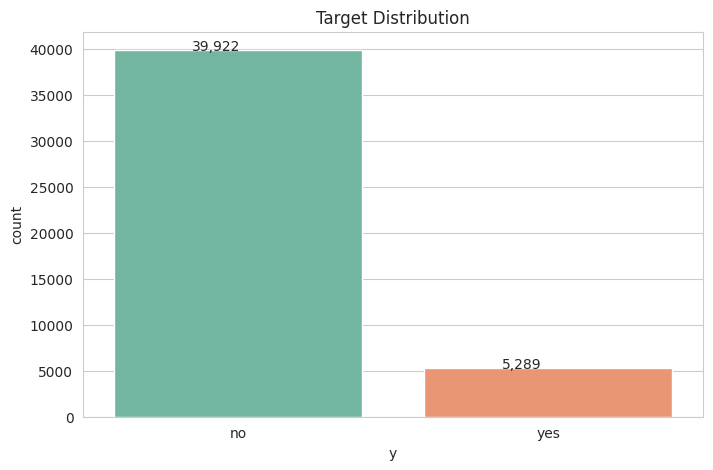

In [ ]:
ax = sns.countplot(
    data=df,
    x="y",
    palette="Set2"
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():,.0f}",
        (p.get_x() + 0.25, p.get_height())
    )

plt.title("Target Distribution")
plt.show()

Dataset is highly imbalanced.

Only around 11% customers subscribed.

Feature Typing

In [ ]:
numerical_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

categorical_cols = df.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical")
print(numerical_cols)

print("\nCategorical")
print(categorical_cols)

Numerical
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']


In [ ]:
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


In [ ]:
selected_numerical_cols = ['balance', 'duration', 'campaign', 'pdays', 'previous']

insight_summary = df[selected_numerical_cols].describe().T
insight_summary['skew'] = df[selected_numerical_cols].skew()
insight_summary['kurt'] = df[selected_numerical_cols].kurt()

insight_summary

,count,mean,std,min,25%,50%,75%,max,skew,kurt
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0,8.360308,140.751547
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0,3.144318,18.153915
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0,4.898650,39.249651
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0,2.615715,6.935195
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0,41.846454,4506.860660


From the output, we can observe:

- Balance: Has a very high maximum value (102127) and a negative minimum (-8019), suggesting potential outliers or interesting financial situations. The high skewness (8.36) and kurtosis (140.75) indicate a highly right-skewed distribution with a sharp peak and heavy tails, meaning most values are clustered at the lower end but there are extreme positive values.

- Duration: The maximum duration is 4918 seconds (approx 82 minutes), with a mean of 258 seconds (approx 4.3 minutes). It is also right-skewed (3.14) with high kurtosis (18.15).
- Campaign: The number of contacts performed during this campaign for this client shows a maximum of 63. The distribution is highly skewed (4.89) and has high kurtosis (39.24).
- Pdays: The number of days that passed after the client was last contacted from a previous campaign. A value of -1 indicates the client was not previously contacted. The mean is 40.19, and the distribution is also right-skewed (2.61) with high kurtosis (6.93).
- Previous: The number of contacts performed before this campaign and for this client shows a maximum of 275. This column also exhibits extreme skewness (41.84) and kurtosis (4506.86), indicating a large number of clients with zero previous contacts and a few with very many.

## Boxplots for Numerical Columns to Detect Outliers

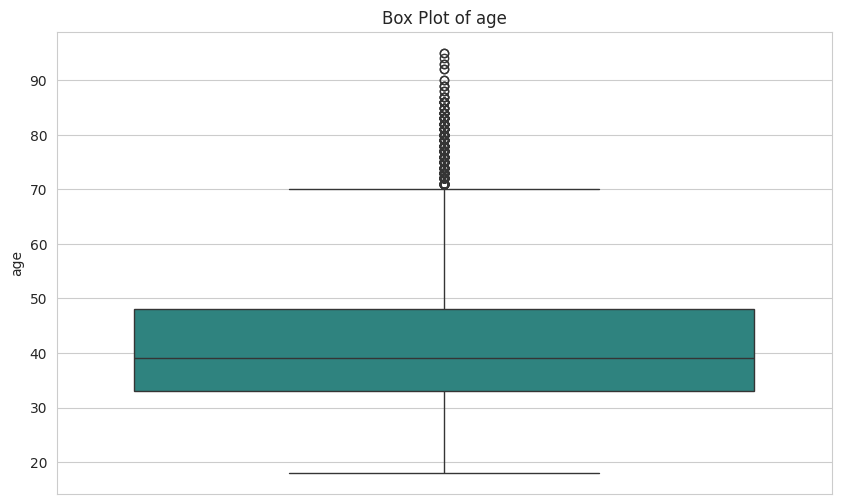

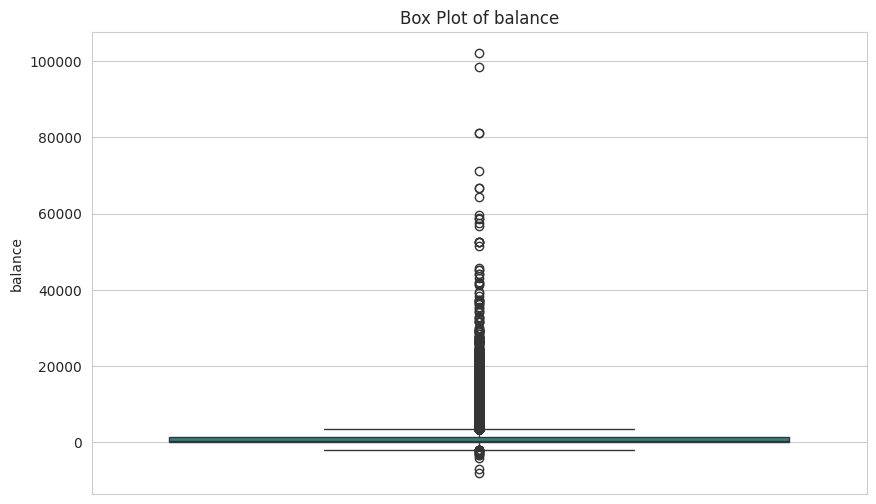

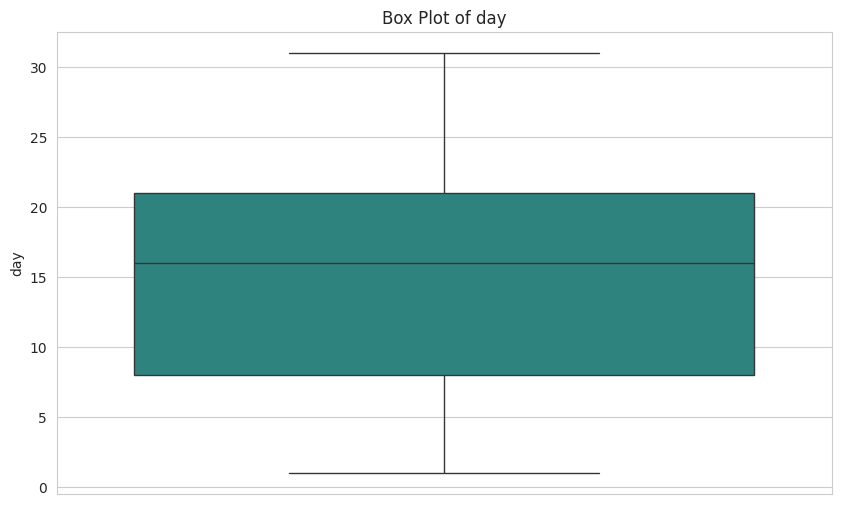

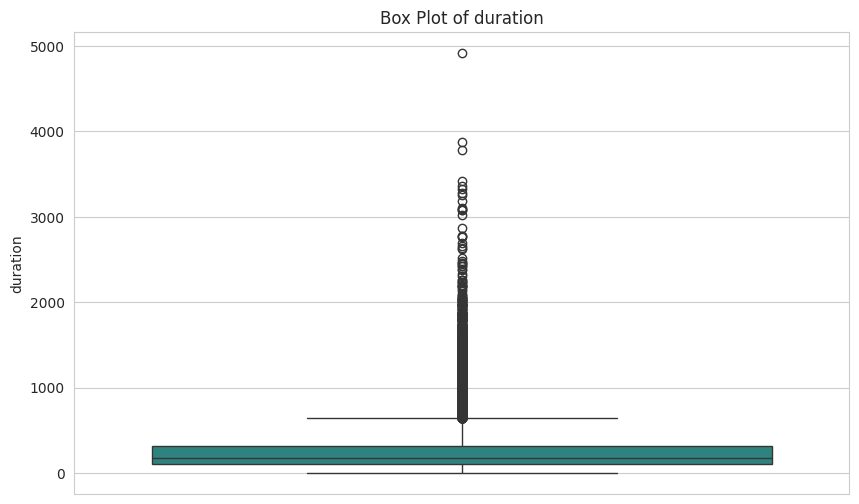

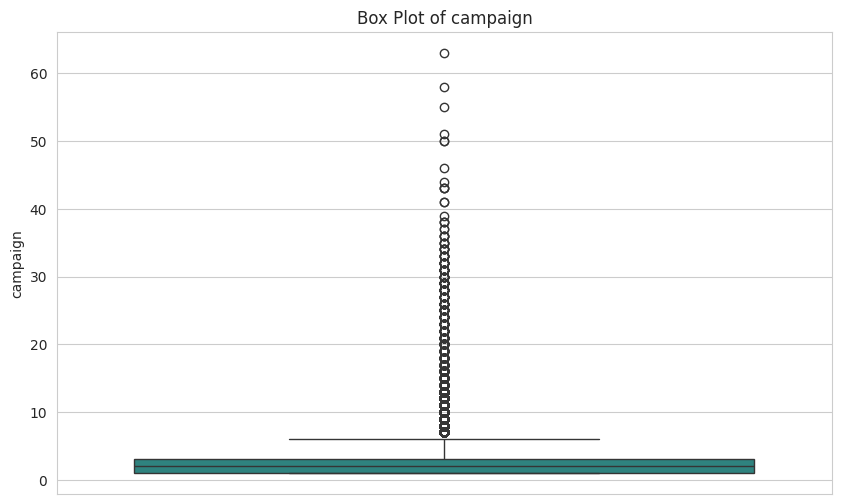

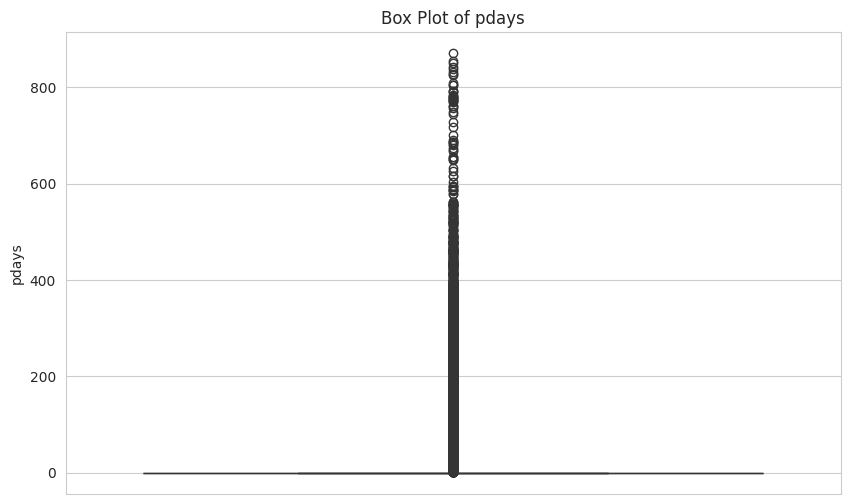

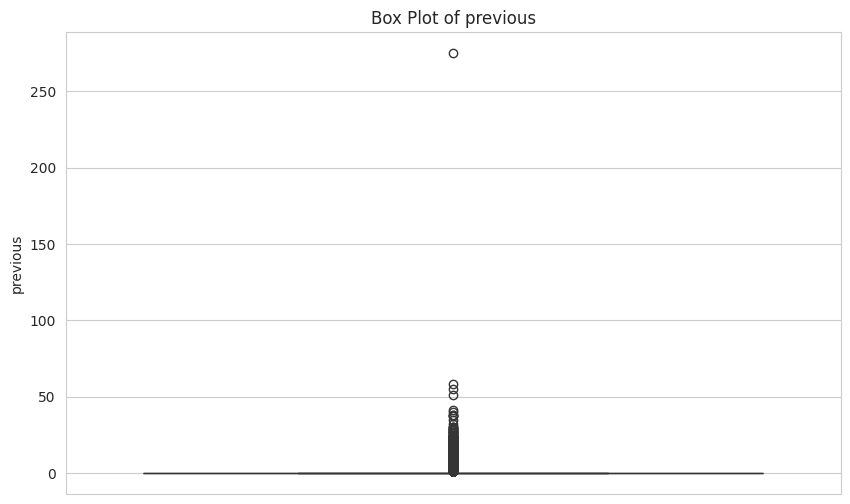

In [ ]:
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(y=df[col], palette='viridis')
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.show()

## Contextual Analysis of Outliers

The box plots clearly indicated the presence of outliers in several numerical columns. To understand their nature better and determine if they are valuable or just noise, we will perform a contextual analysis. This involves looking at their distribution more closely and examining their relationship with the target variable.

### Distribution of Key Numerical Features (Histograms and KDE)

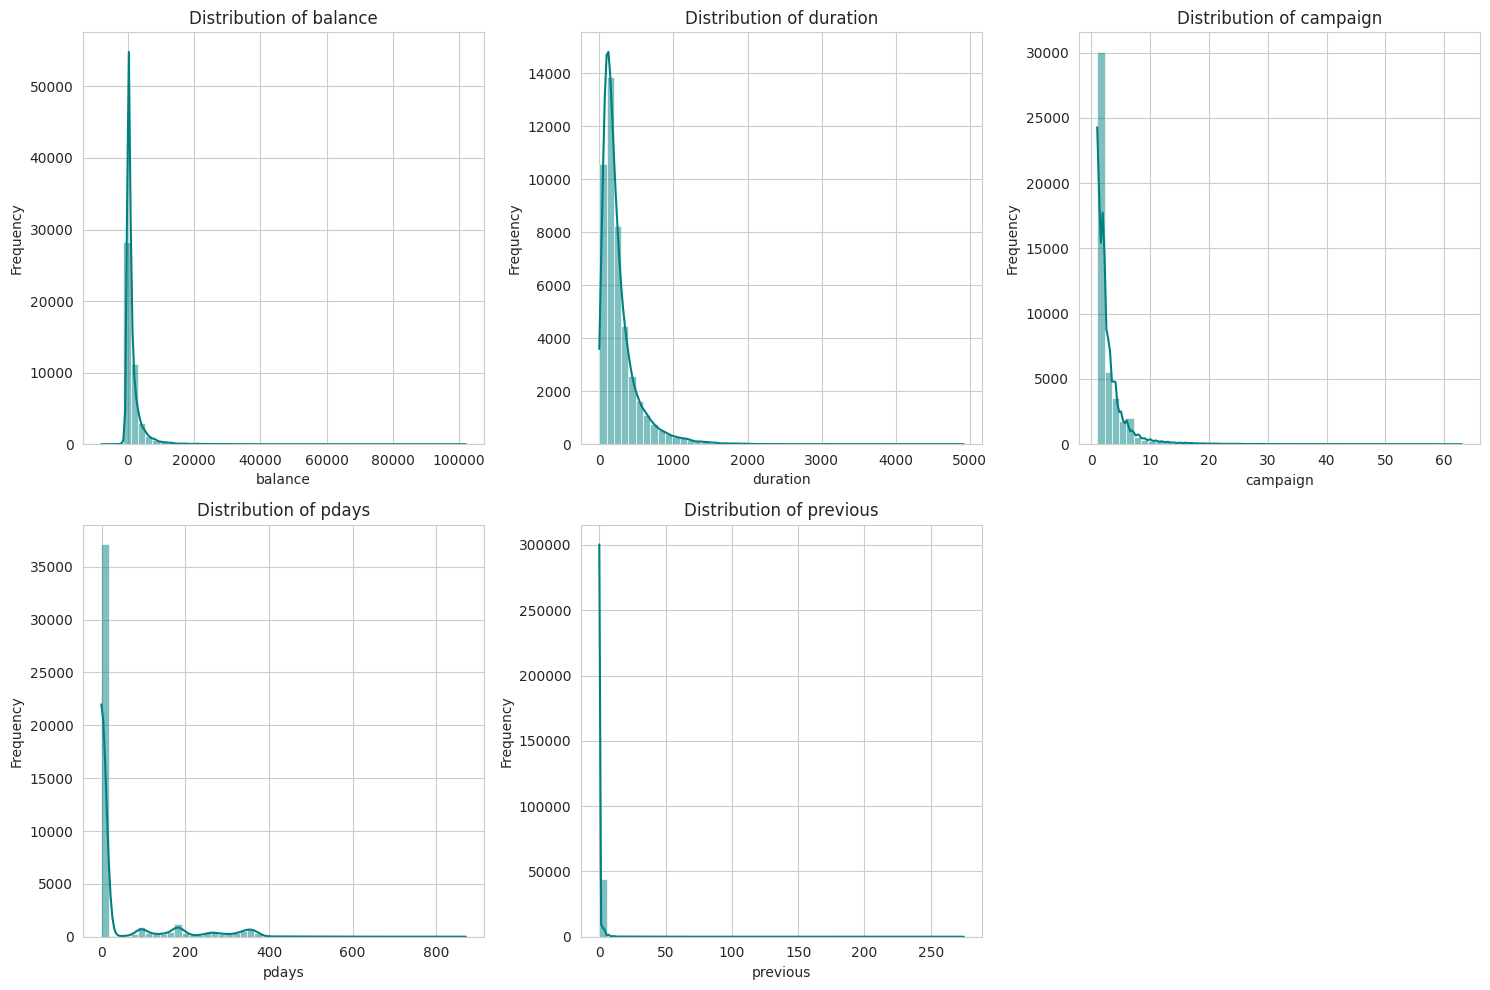

In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(selected_numerical_cols):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid based on number of columns
    sns.histplot(df[col], kde=True, bins=50, color='teal')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Analyzing `pdays` special value (-1)

The `pdays` column has a special value of -1, indicating that the client was not previously contacted. This is not a numerical outlier in the traditional sense but a categorical indicator. Let's analyze the conversion rate based on whether a client was previously contacted or not.

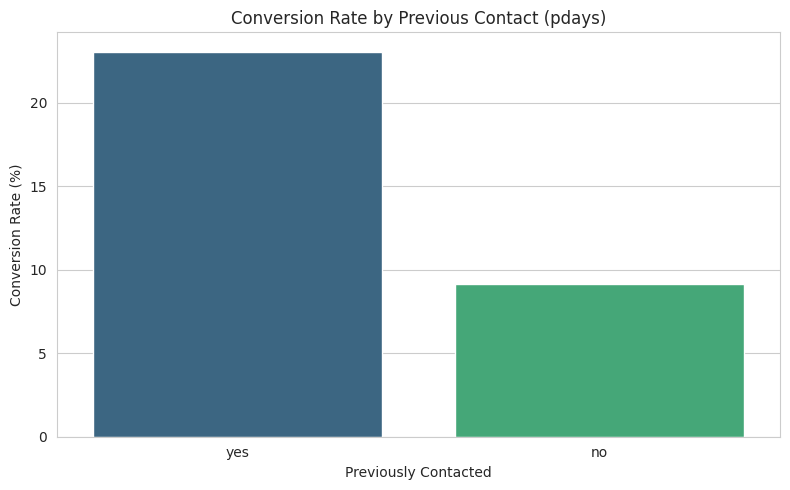

y,no,yes,yes_rate
pdays_contacted,,,
yes,0.769287,0.230713,23.071333
no,0.908427,0.091573,9.157331


In [ ]:
# Create a new feature to categorize pdays
df['pdays_contacted'] = df['pdays'].apply(lambda x: 'yes' if x != -1 else 'no')

pdays_conversion = df.groupby('pdays_contacted')['y'].value_counts(normalize=True).unstack()
pdays_conversion['yes_rate'] = pdays_conversion['yes'] * 100
pdays_conversion = pdays_conversion.sort_values(by='yes_rate', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=pdays_conversion.index, y=pdays_conversion['yes_rate'], palette='viridis')
plt.title('Conversion Rate by Previous Contact (pdays)')
plt.xlabel('Previously Contacted')
plt.ylabel('Conversion Rate (%)')
plt.tight_layout()
plt.show()

display(pdays_conversion)

### Conversion Rate for Extreme Values

To see if the extreme values are valuable, we can analyze the conversion rate for customers falling into these extreme ranges. For instance, let's examine customers with unusually high `balance` or `duration` and compare their conversion rates to the overall average.

In [ ]:
# Define thresholds for 'extreme' values. For simplicity, let's use the 99th percentile for positive outliers
# and 1st percentile for negative outliers (like in balance).

outlier_cols = ['balance', 'duration', 'campaign', 'previous'] # pdays handled separately

for col in outlier_cols:
    if df[col].min() < 0: # Handle negative outliers like in balance
        lower_bound = df[col].quantile(0.01)
        extreme_lower_df = df[df[col] <= lower_bound]
        if not extreme_lower_df.empty:
            lower_conversion_rate = extreme_lower_df['y'].value_counts(normalize=True).get('yes', 0) * 100
            print(f"Conversion rate for extreme LOW {col} (<= {lower_bound:.2f}): {lower_conversion_rate:.2f}%")

    upper_bound = df[col].quantile(0.99)
    extreme_upper_df = df[df[col] >= upper_bound]
    if not extreme_upper_df.empty:
        upper_conversion_rate = extreme_upper_df['y'].value_counts(normalize=True).get('yes', 0) * 100
        print(f"Conversion rate for extreme HIGH {col} (>= {upper_bound:.2f}): {upper_conversion_rate:.2f}%")

print(f"\nOverall conversion rate: {target_dist.get('yes', 0):.2f}%")

Conversion rate for extreme LOW balance (<= -627.00): 5.07%
Conversion rate for extreme HIGH balance (>= 13164.90): 11.92%
Conversion rate for extreme HIGH duration (>= 1269.00): 61.45%
Conversion rate for extreme HIGH campaign (>= 16.00): 2.45%
Conversion rate for extreme HIGH previous (>= 8.90): 22.96%

Overall conversion rate: 11.70%


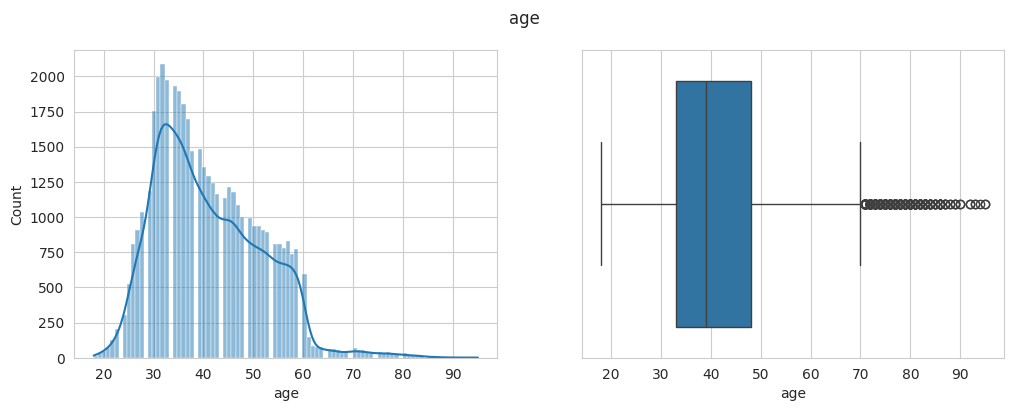

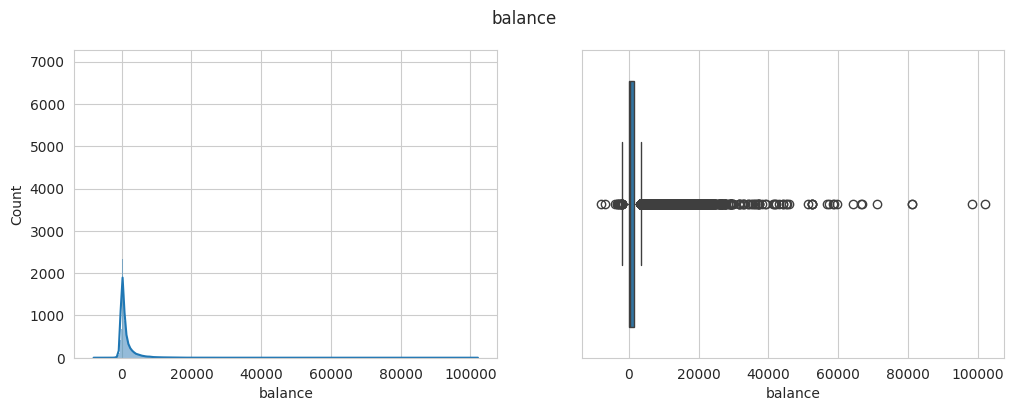

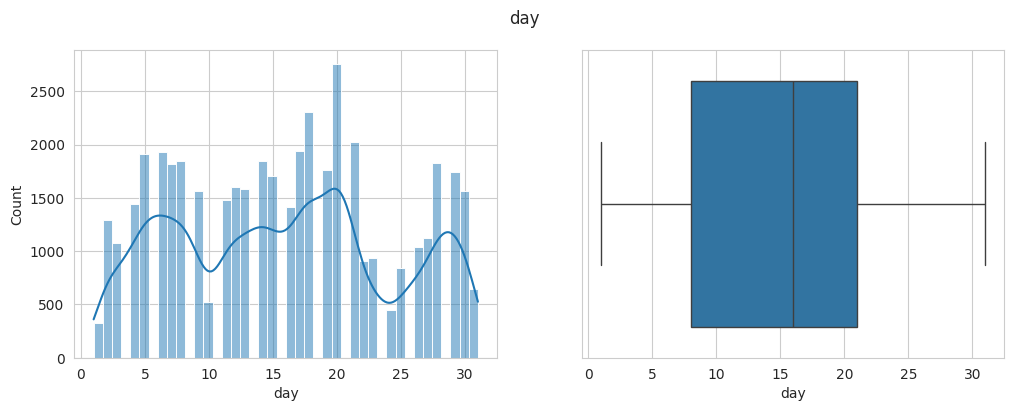

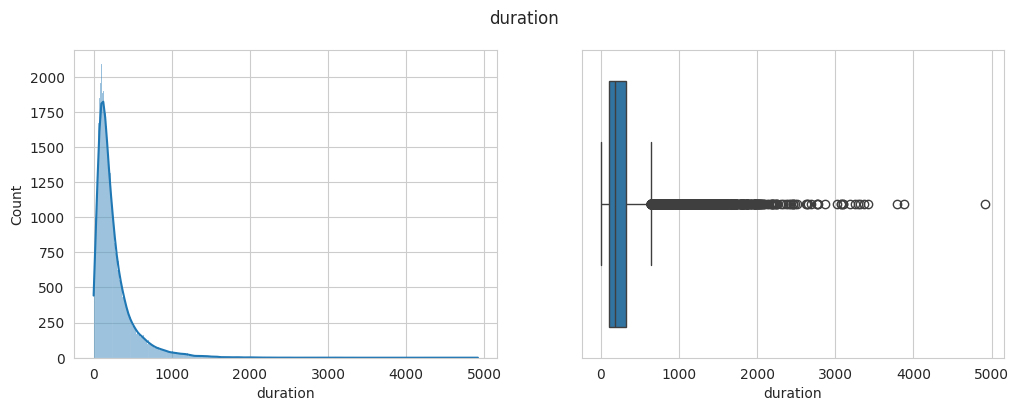

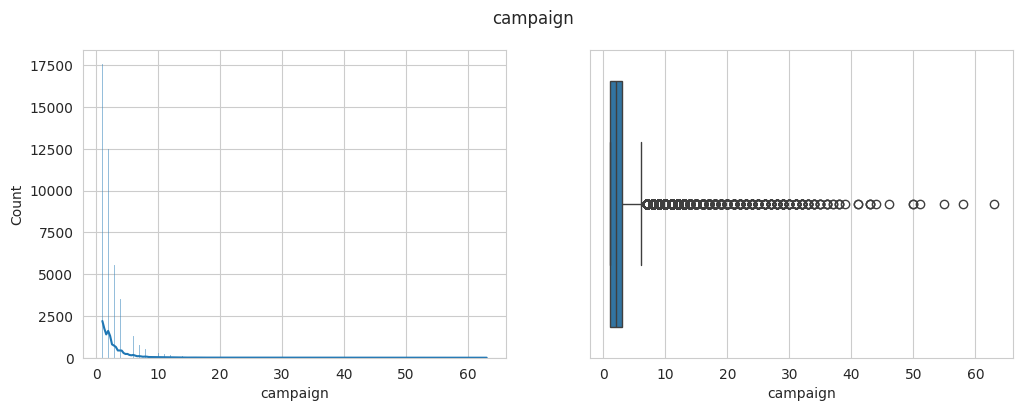

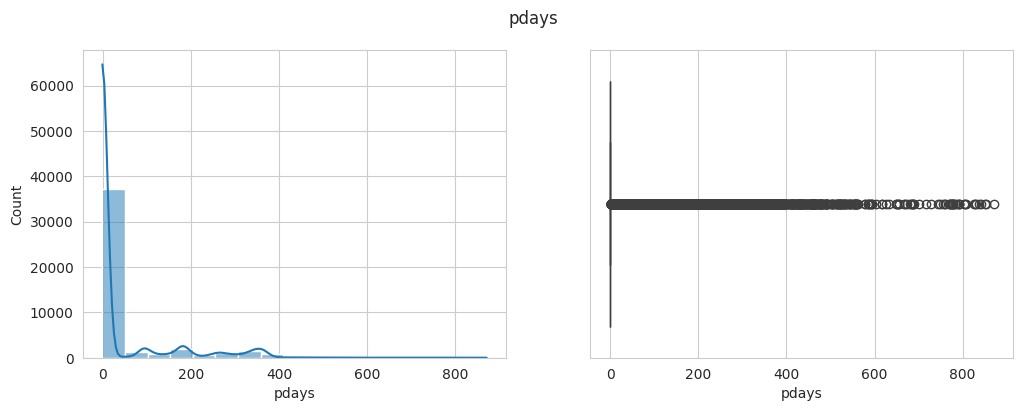

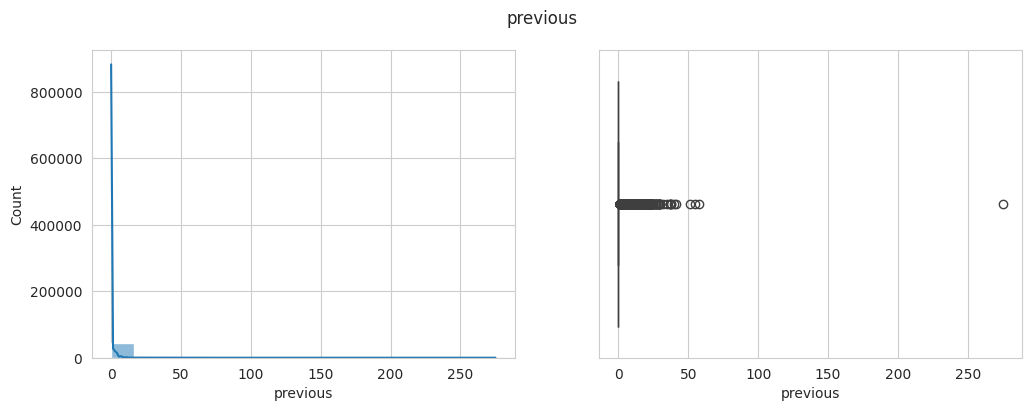

In [25]:
for col in numerical_cols:

    fig, ax = plt.subplots(
        1,2,
        figsize=(12,4)
    )

    sns.histplot(
        df[col],
        kde=True,
        ax=ax[0]
    )

    sns.boxplot(
        x=df[col],
        ax=ax[1]
    )

    plt.suptitle(col)

    plt.show()

In [26]:
df["age_bin"] = pd.cut(
    df["age"],
    bins=[18,25,35,45,55,65,100]
)

age_conv = (
    df.groupby("age_bin")["y"]
    .apply(lambda x: (x=="yes").mean())
    .reset_index()
)

age_conv

,age_bin,y
0,"(18, 25]",0.236405
1,"(25, 35]",0.120031
2,"(35, 45]",0.093894
3,"(45, 55]",0.093527
4,"(55, 65]",0.141239
5,"(65, 100]",0.426099


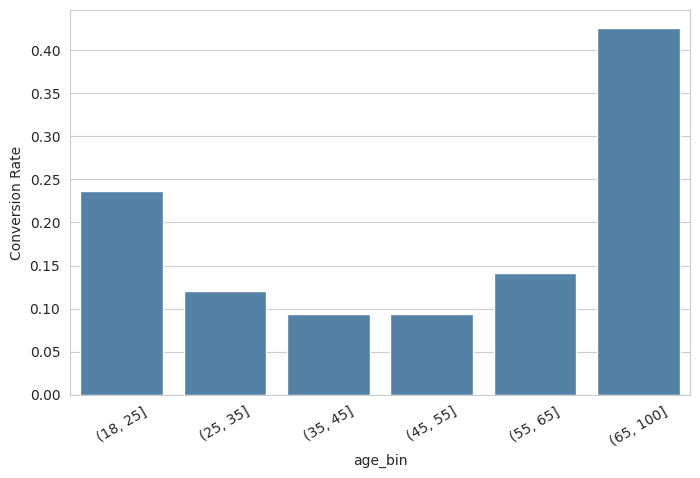

In [27]:
sns.barplot(
    data=age_conv,
    x="age_bin",
    y="y",
    color="steelblue"
)

plt.xticks(rotation=30)
plt.ylabel("Conversion Rate")

plt.show()

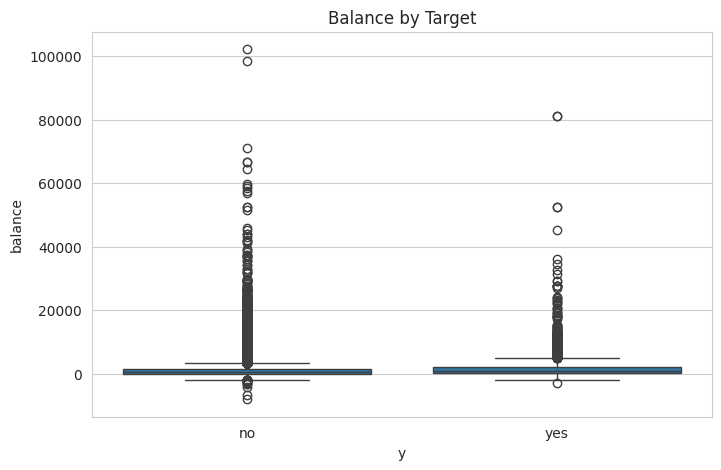

In [28]:
sns.boxplot(
    data=df,
    x="y",
    y="balance"
)

plt.title("Balance by Target")
plt.show()

## Correlation Analysis using Heatmap

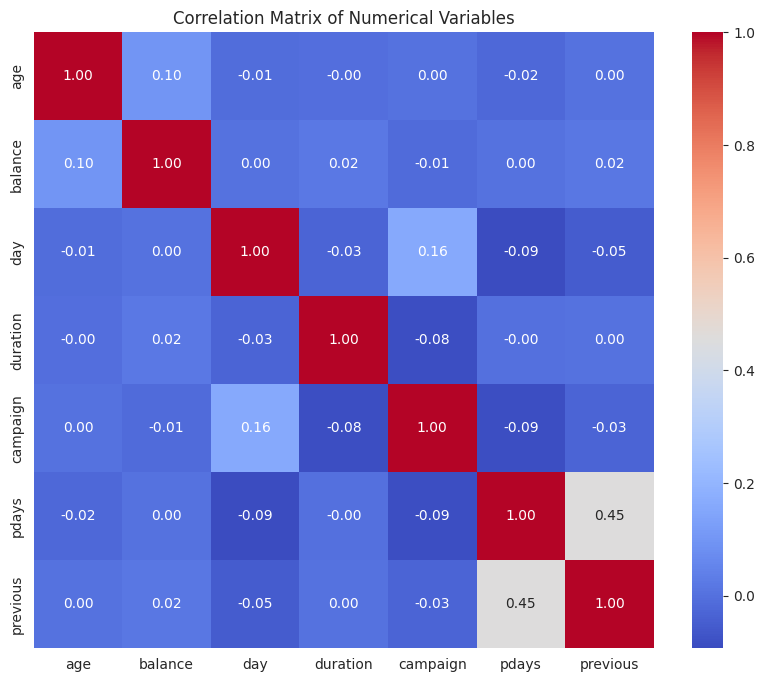

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

## 2. Categorical Understanding

In [29]:
for col in categorical_cols:

    print("="*50)
    print(col)

    print(df[col].value_counts().head(10))

job
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
Name: count, dtype: int64
marital
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64
education
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64
default
default
no     44396
yes      815
Name: count, dtype: int64
housing
housing
yes    25130
no     20081
Name: count, dtype: int64
loan
loan
no     37967
yes     7244
Name: count, dtype: int64
contact
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64
month
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
Name: count, dtype: int64
poutcome
poutcome
unknown    36959
failure     4901
other      

In [30]:
for col in categorical_cols:

    if "unknown" in df[col].astype(str).unique():

        print(
            col,
            (df[col] == "unknown").mean()
        )

job 0.006370131162770122
education 0.04107407489327818
contact 0.28798301298356593
poutcome 0.8174780473778506


In [31]:
target_map = {
    "yes":1,
    "no":0
}

df["target"] = df["y"].map(target_map)

In [32]:
def conversion_rate_plot(df, feature):

    temp = (
        df.groupby(feature)
        .agg(
            conversion_rate=("target","mean"),
            count=("target","size")
        )
        .reset_index()
        .sort_values(
            "conversion_rate",
            ascending=False
        )
    )

    plt.figure(figsize=(10,5))

    sns.barplot(
        data=temp,
        x=feature,
        y="conversion_rate"
    )

    plt.xticks(rotation=45)
    plt.title(feature)

    plt.show()

    return temp

## Conversion Rate by Job

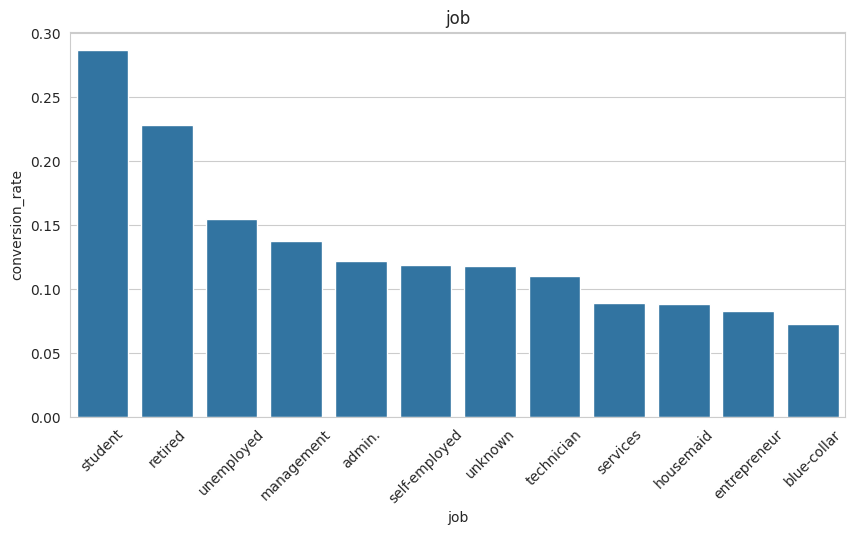

,job,conversion_rate,count
8,student,0.286780,938
5,retired,0.227915,2264
10,unemployed,0.155027,1303
4,management,0.137556,9458
0,admin.,0.122027,5171
6,self-employed,0.118429,1579
11,unknown,0.118056,288
9,technician,0.110570,7597
7,services,0.088830,4154
3,housemaid,0.087903,1240


In [33]:
conversion_rate_plot(df, "job")

## Conversion Rate by Education

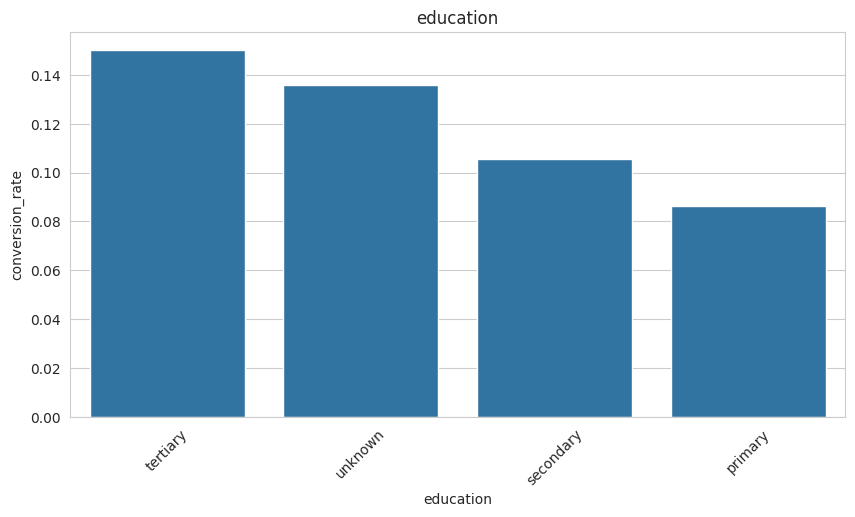

,education,conversion_rate,count
2,tertiary,0.150064,13301
3,unknown,0.135703,1857
1,secondary,0.105594,23202
0,primary,0.086265,6851


In [34]:
conversion_rate_plot(df, "education")

Conversion Rate by Marital status

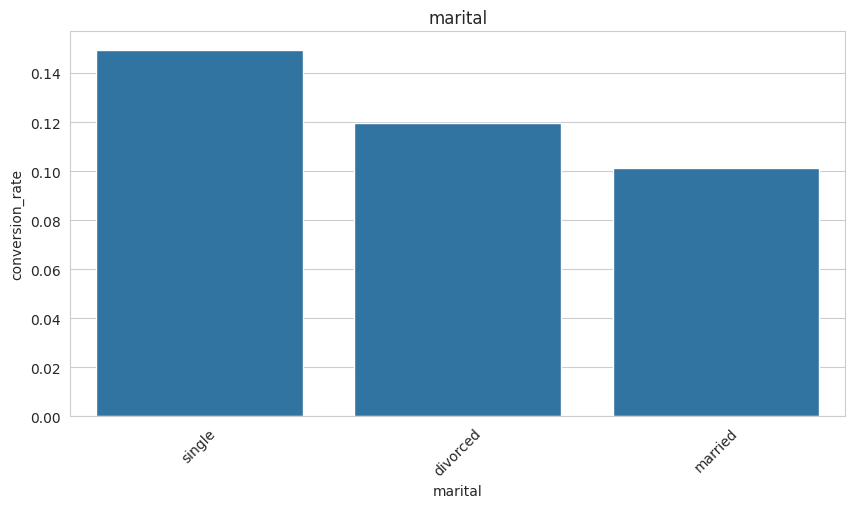

,marital,conversion_rate,count
2,single,0.149492,12790
0,divorced,0.119455,5207
1,married,0.101235,27214


In [35]:
conversion_rate_plot(df, "marital")

## Conversion Rate by Housing Loan

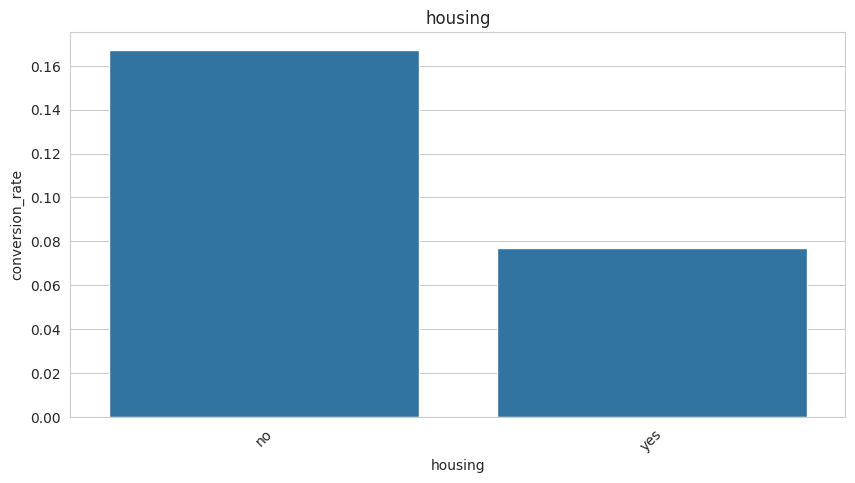

,housing,conversion_rate,count
0,no,0.167024,20081
1,yes,0.077000,25130


In [36]:
conversion_rate_plot(df, "housing")

## Conversion Rate by Personal Loan

---



---



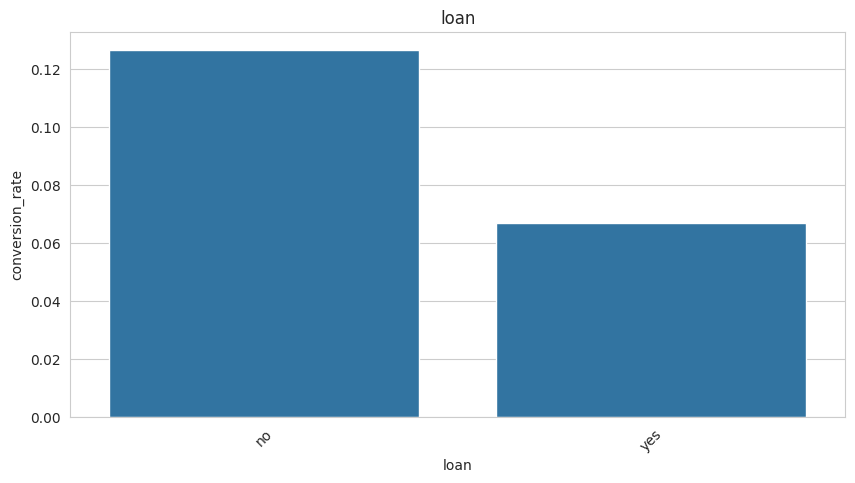

,loan,conversion_rate,count
0,no,0.126557,37967
1,yes,0.066814,7244


In [37]:
conversion_rate_plot(df, "loan")

## Conversion Rate by Campaign Analysis

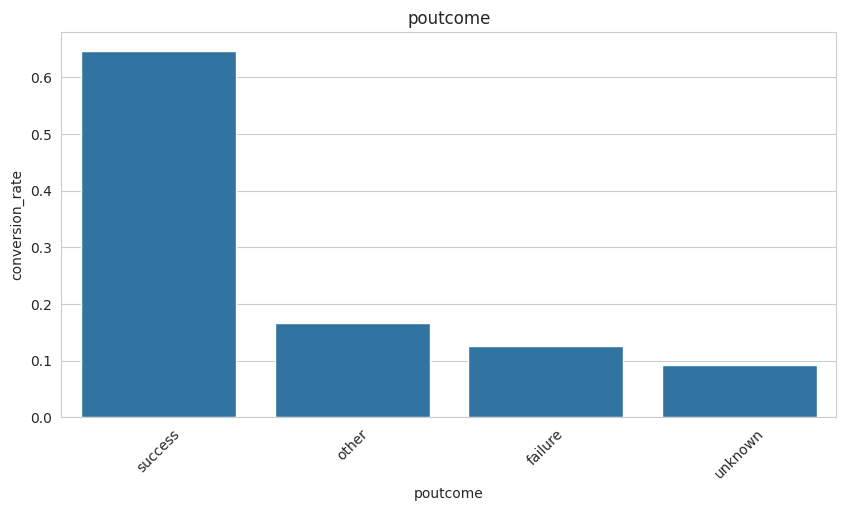

,poutcome,conversion_rate,count
2,success,0.647253,1511
1,other,0.166848,1840
0,failure,0.126097,4901
3,unknown,0.091615,36959


In [38]:
conversion_rate_plot(df, "poutcome")

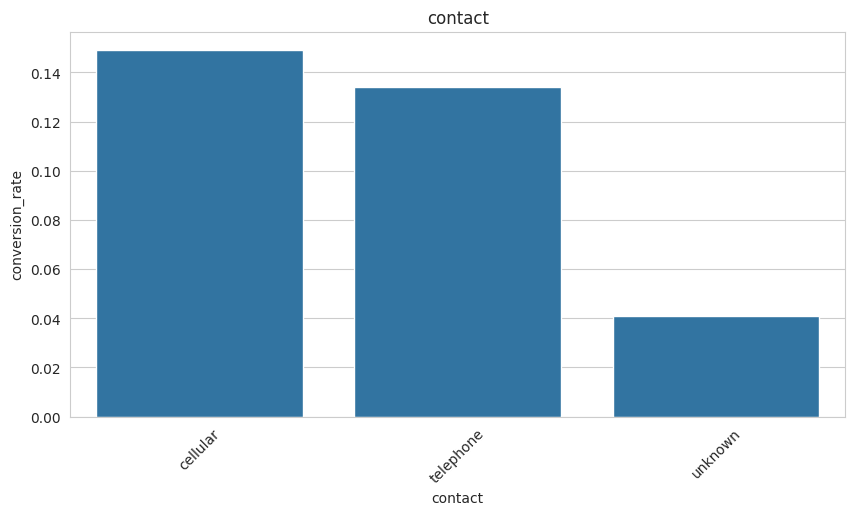

,contact,conversion_rate,count
0,cellular,0.149189,29285
1,telephone,0.134205,2906
2,unknown,0.040707,13020


In [39]:
conversion_rate_plot(df, "contact")

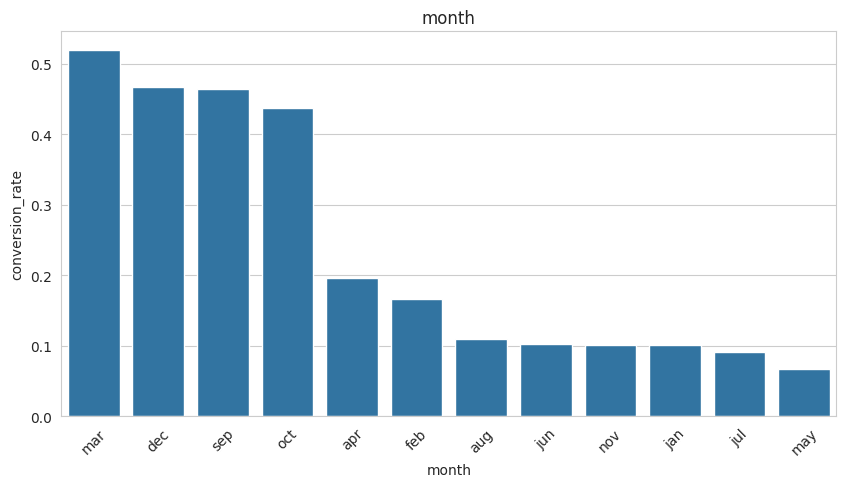

,month,conversion_rate,count
7,mar,0.519916,477
2,dec,0.467290,214
11,sep,0.464594,579
10,oct,0.437669,738
0,apr,0.196794,2932
3,feb,0.166478,2649
1,aug,0.110133,6247
6,jun,0.102228,5341
9,nov,0.101511,3970
4,jan,0.101212,1403


In [40]:
conversion_rate_plot(df, "month")

## 3. Mutual Information

In [41]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

In [44]:
mi_df = df.copy()

# Columns that were initially identified as categorical, plus 'age_bin' and 'pdays_contacted'
# Exclude 'y' from this list, as 'target' is the numerical target variable
# and 'y' will be dropped from X anyway.
all_categorical_features_for_encoding = [col for col in categorical_cols if col != 'y']

# Add 'age_bin' if it exists in mi_df and is of a categorical type
if 'age_bin' in mi_df.columns and (mi_df['age_bin'].dtype.name == 'category' or mi_df['age_bin'].dtype == 'object'):
    all_categorical_features_for_encoding.append('age_bin')

# Add 'pdays_contacted' if it exists in mi_df and is of a categorical type
if 'pdays_contacted' in mi_df.columns and (mi_df['pdays_contacted'].dtype.name == 'category' or mi_df['pdays_contacted'].dtype == 'object'):
    all_categorical_features_for_encoding.append('pdays_contacted')

for col in all_categorical_features_for_encoding:
    # Ensure no NaNs before LabelEncoding. pd.cut can create NaNs if values fall outside bins.
    # Convert to string to allow filling with 'Unknown' as a new category.
    if mi_df[col].isnull().any():
        mi_df[col] = mi_df[col].astype(str).fillna('Unknown')

    mi_df[col] = LabelEncoder().fit_transform(
        mi_df[col]
    )

# X should contain all features for mutual information calculation
# Drop the original 'y' column (string 'yes'/'no') and the 'target' column (numerical 0/1)
# as 'target' is the dependent variable 'y' for mutual_info_classif
X = mi_df.drop(
    columns=["y","target"]
)

# y is the target variable for mutual information calculation
y = mi_df["target"]

# Now X should only contain numerical features, all without NaNs
mi = mutual_info_classif(
    X,
    y,
    random_state=42
)

mi_result = pd.DataFrame({
    "feature": X.columns,
    "mi": mi
})

mi_result.sort_values(
    "mi",
    ascending=False
)

,feature,mi
11,duration,0.071254
15,poutcome,0.036195
13,pdays,0.027347
10,month,0.024089
5,balance,0.022101
8,contact,0.015706
16,pdays_contacted,0.014277
6,housing,0.013788
14,previous,0.013105
0,age,0.011405


The Mutual Information (MI) results indicate how much each feature contributes to predicting the target variable. Here's what the sorted results suggest:

- 'duration' has the highest MI score (0.071254), confirming its strong relationship with the target variable. This is expected as longer call durations often correlate with successful conversions.
- 'poutcome' (previous outcome) also shows a significant MI score (0.036195), meaning past campaign results are highly informative.
- 'pdays' (days since last contact) and 'month' (last contact month) are also important features, with MI scores of 0.027347 and 0.024089 respectively.
- 'balance' and 'contact' have moderate MI scores, suggesting they offer some predictive power.
- Features like 'campaign', 'loan', and 'default' have the lowest MI scores, indicating they are less informative individually about whether a customer will subscribe.

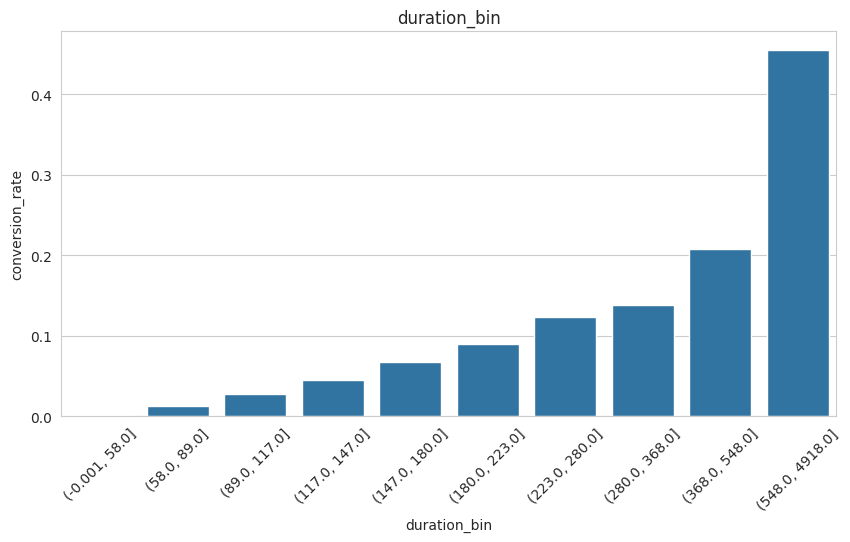

,duration_bin,conversion_rate,count
9,"(548.0, 4918.0]",0.455413,4508
8,"(368.0, 548.0]",0.208527,4527
7,"(280.0, 368.0]",0.137869,4468
6,"(223.0, 280.0]",0.123312,4517
5,"(180.0, 223.0]",0.090488,4531
4,"(147.0, 180.0]",0.068060,4496
3,"(117.0, 147.0]",0.045793,4564
2,"(89.0, 117.0]",0.028476,4495
1,"(58.0, 89.0]",0.012456,4576
0,"(-0.001, 58.0]",0.001987,4529


In [45]:
conversion_rate_plot(
    df.assign(
        duration_bin=pd.qcut(
            df["duration"],
            q=10,
            duplicates="drop"
        )
    ),
    "duration_bin"
)

Duration is known only after a call ends.

Therefore it may create target leakage if the model is intended
to score customers before contacting them.